In [1]:
# Cell 1 — Drive Mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2 — Install Libraries
!pip install -q langchain langgraph langchain-openai langchain-community
!pip install -q chromadb pypdf openai tiktoken langchain-text-splitters
print('✅ Sab libraries install ho gayi!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [ ]:
# Cell 3 — Configuration
import os

# OpenAI API Key
os.environ["OPENAI_API_KEY"] = "sk"  # <-- apni key daalo

# PDF Paths — nayi file add karni ho toh bas yahan add karo
PDF_PATHS = [
    "/content/drive/MyDrive/BTP_Project/documents/HCI1.pdf",
    # "/content/drive/MyDrive/BTP_Project/documents/file2.pdf",  # baad mein
]

# Page filte
START_PAGE = 45

# Paths
CHROMA_PATH  = "/content/drive/MyDrive/BTP_Project/chromadb"  # local — fast, no permission issues
TRACKER_PATH = "/content/drive/MyDrive/BTP_Project/processed_files.txt"  # Drive pe

print('✅ Config ready!')

✅ Config ready!


In [4]:
# Cell 4 — Build Knowledge Base
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
import os

# Models
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

# Tracker functions
def get_processed_files():
    if os.path.exists(TRACKER_PATH):
        with open(TRACKER_PATH, "r") as f:
            return set(f.read().splitlines())
    return set()

def mark_file_processed(filepath):
    os.makedirs(os.path.dirname(TRACKER_PATH), exist_ok=True)
    with open(TRACKER_PATH, "a") as f:
        f.write(filepath + "\n")

# Build / Load DB
def build_knowledge_base():
    vectordb = Chroma(
        persist_directory=CHROMA_PATH,
        embedding_function=embedding_model
    )

    # 🔥 FIX: check if DB already has data
    existing_chunks = vectordb._collection.count()
    print(f"📦 Existing chunks in DB: {existing_chunks}")

    processed = get_processed_files()

    # 🔥 SAFETY: agar DB empty hai → tracker ignore
    if existing_chunks == 0:
        print("⚠️ DB empty hai → tracker reset")
        processed = set()

    new_files = 0

    for pdf_path in PDF_PATHS:
        if pdf_path in processed:
            print(f"⏭️ Already processed: {pdf_path.split('/')[-1]}")
            continue

        if not os.path.exists(pdf_path):
            print(f"❌ File nahi mili: {pdf_path.split('/')[-1]}")
            continue

        print(f"📚 Loading: {pdf_path.split('/')[-1]}...")
        docs = PyPDFLoader(pdf_path).load()

        # Page filter
        docs = [doc for doc in docs if int(doc.metadata.get('page', 0)) >= START_PAGE]
        print(f"   📄 {len(docs)} relevant pages mile!")

        # Split
        chunks = splitter.split_documents(docs)
        print(f"   ✂️ {len(chunks)} chunks bane!")

        # Store
        vectordb.add_documents(chunks)
        vectordb.persist()   # 🔥 MOST IMPORTANT LINE

        mark_file_processed(pdf_path)

        print(f"✅ Stored successfully!\n")
        new_files += 1

    if new_files == 0:
        print("✅ No new files — using existing DB")
    else:
        print("🎉 Knowledge base updated!")

    return vectordb


vectordb = build_knowledge_base()

/tmp/ipykernel_17906/2180429857.py:26: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectordb = Chroma(


📦 Existing chunks in DB: 3389
⏭️ Already processed: HCI1.pdf
✅ No new files — using existing DB


In [5]:
# Test retrieval
query = "What is HCI?"
results = vectordb.similarity_search(query, k=25)

print(f"🔍 Query: {query}\n")
for i, doc in enumerate(results, 1):
    print(f"--- Chunk {i} ---")
    print(doc.page_content[:300])
    print()

🔍 Query: What is HCI?

--- Chunk 1 ---
HIT. See Human Intelligence Task
Hitwise, 167
HMD. See Head-mounted display
HoloLens, 303, 336
HomeAssist, 47
Home Designer Software, 213
Honeywell, 213
Hotkeys. See Keyboard shortcuts
Hotlinks, 242
Hound, 283
HSI. See Human Systems Integration
HTC Vive, 225

--- Chunk 2 ---
H
Habitability, 292
HAL 9000, 280
Hamburger menu, 245
Handbook of human needs, 539
Hand sensors, 326–327
Handwriting recognition, 310
Hangouts, 157
Haptic feedback, 327–328
Hardware diversity, 52–53
HCI. See Human-computer interaction
Headings, guidelines for, 60
Head-mounted display (HMD), 336
Head

--- Chunk 3 ---
HTML, 128, 241, 405
Huffington Post, 360
Human-centered participatory design, 545
Human-computer interaction (HCI), 6–7
challenges for, 537–547
displays for, 393
prototypes for, 114
psychology for, 21
research on, 20–22
Human Factors Engineering of Computer Workstations (HFES),
38–39
Human Factors &

--- Chunk 4 ---
community processes of civic participation, democ

In [6]:
# Cell 6 — LangGraph Setup
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

class AssessmentState(TypedDict):
    question: str
    student_answer: str

    retrieved_chunks: List[str]
    context: str

    concepts: dict
    scores: dict

    feedback: str

print("✅ LangGraph + LLM ready!")

✅ LangGraph + LLM ready!


In [7]:
# Cell 7 — Retrieval Node
from langchain_core.prompts import ChatPromptTemplate

def retrieval_node(state: AssessmentState) -> AssessmentState:
    """
    Mandatory RAG step — yahi tera core novelty hai!
    LLM iske bina aage nahi ja sakta.
    """
    print("🔍 Retrieving relevant content from HCI textbook...")

    # ✅ Better query (question only)
    query = state["question"]
    results = vectordb.similarity_search(query, k=4)

    chunks = [doc.page_content for doc in results]
    state["retrieved_chunks"] = chunks

    # ✅ combined context (VERY IMPORTANT)
    context = "\n\n".join(chunks)
    state["context"] = context

    print(f"✅ {len(chunks)} relevant chunks retrieved!")
    return state

print("✅ Retrieval Node ready!")

✅ Retrieval Node ready!


In [8]:
# NEW — Concept Analysis Node
def concept_node(state: AssessmentState) -> AssessmentState:
    print("🧠 Analyzing concepts...")

    context = state["context"]

    prompt = ChatPromptTemplate.from_template("""
You are an HCI examiner.

QUESTION:
{question}

STUDENT ANSWER:
{student_answer}

REFERENCE MATERIAL:
{context}

TASK:
1. Extract key concepts from reference
2. Check if student covered them

Return ONLY JSON:
{{
  "concepts": [
    {{
      "name": "concept name",
      "status": "covered / partial / missing",
      "justification": "short reason"
    }}
  ]
}}
""")

    chain = prompt | llm
    result = chain.invoke({
        "question": state["question"],
        "student_answer": state["student_answer"],
        "context": context
    })

    state["concepts"] = result.content

    print("✅ Concept analysis done!")
    return state

In [9]:
# Cell 8 — Scoring Node (UPGRADED)
def scoring_node(state: AssessmentState) -> AssessmentState:
    print("🎯 Scoring student answer...")

    context = state["context"]              # ✅ use clean context
    concepts = state["concepts"]            # ✅ NEW

    prompt = ChatPromptTemplate.from_template(
        """
You are a STRICT HCI examiner.

IMPORTANT RULES:
- Use ONLY the provided reference material
- Be very strict in marking
- DO NOT give full marks unless answer is PERFECT
- Deduct marks for:
  - Missing concepts
  - Lack of depth
  - Partial explanations

QUESTION:
{question}

REFERENCE:
{context}

STUDENT ANSWER:
{student_answer}

CONCEPT ANALYSIS:
{concepts}

RUBRIC:

Concept Accuracy:
- 9-10 → All key concepts correct
- 6-8 → Minor mistakes
- 3-5 → Partial understanding
- 0-2 → Incorrect

Completeness:
- 9-10 → Fully covers all points
- 6-8 → Some points missing
- 3-5 → Many missing
- 0-2 → Very incomplete

Logical Coherence:
- 9-10 → Very clear structure
- 6-8 → Some issues
- 3-5 → Poor structure
- 0-2 → Disorganized

Terminology:
- 9-10 → Proper terms used
- 6-8 → Minor issues
- 3-5 → Weak usage
- 0-2 → Incorrect terms

Return ONLY JSON:
{{
  "concept_accuracy": int,
  "completeness": int,
  "logical_coherence": int,
  "terminology": int,
  "total": int
}}
"""
    )

    chain = prompt | llm
    result = chain.invoke({
        "question": state["question"],
        "context": context,
        "student_answer": state["student_answer"],
        "concepts": concepts
    })

    # ✅ Store raw JSON string (later parse kar sakte ho)
    state["scores"] = result.content

    print("✅ Scoring done!")
    return state

print("✅ Scoring Node ready!")

✅ Scoring Node ready!


In [10]:
# Cell 9 — Feedback Node (UPGRADED)
def feedback_node(state: AssessmentState) -> AssessmentState:
    print("💬 Generating grounded feedback...")

    context = state["context"]          # ✅ clean context
    concepts = state["concepts"]        # ✅ NEW
    scores = state["scores"]            # ✅ JSON scores

    prompt = ChatPromptTemplate.from_template("""
You are an HCI tutor giving structured, concept-aware feedback.

IMPORTANT:
- Use ONLY the provided reference material
- Base your feedback on concept analysis and scores

QUESTION:
{question}

STUDENT ANSWER:
{student_answer}

REFERENCE MATERIAL:
{context}

CONCEPT ANALYSIS:
{concepts}

SCORES:
{scores}

TASK:
Write structured feedback:

1. ✅ What the student did RIGHT (based on covered concepts)
2. ❌ What is MISSING (important concepts not covered)
3. ⚠️ What is PARTIALLY CORRECT
4. 📚 How to IMPROVE (refer to textbook concepts)

Be specific, avoid generic statements.

Keep it clear, concise, and helpful.
""")

    chain = prompt | llm
    result = chain.invoke({
        "question": state["question"],
        "student_answer": state["student_answer"],
        "context": context,
        "concepts": concepts,
        "scores": scores
    })

    state["feedback"] = result.content
    print("✅ Feedback generated!")
    return state

print("✅ Feedback Node ready!")

✅ Feedback Node ready!


In [11]:
# Cell 10 — Build LangGraph Pipeline (UPGRADED)
from langgraph.graph import StateGraph, END

def build_pipeline():
    graph = StateGraph(AssessmentState)

    # Nodes add karo
    graph.add_node("retrieval", retrieval_node)
    graph.add_node("concept_analysis", concept_node)   # ✅ NEW
    graph.add_node("scoring",   scoring_node)
    graph.add_node("feedback",  feedback_node)

    # Execution order (UPDATED 🔥)
    graph.set_entry_point("retrieval")
    graph.add_edge("retrieval", "concept_analysis")   # ✅ NEW
    graph.add_edge("concept_analysis", "scoring")     # ✅ NEW
    graph.add_edge("scoring",   "feedback")
    graph.add_edge("feedback",  END)

    return graph.compile()

# Pipeline build karo
pipeline = build_pipeline()

print("✅ LangGraph Pipeline ready!")
print("   retrieval → concept_analysis → scoring → feedback → END")

✅ LangGraph Pipeline ready!
   retrieval → concept_analysis → scoring → feedback → END


In [12]:
import json

def parse_scores(score_response):
    try:
        return json.loads(score_response)
    except:
        print("⚠️ JSON parsing failed, fallback to 0")
        return {
            "concept_accuracy": 0,
            "completeness": 0,
            "logical_coherence": 0,
            "terminology": 0,
            "total": 0
        }

In [13]:
# Cell 11 — Final Evaluation + Strict Grading Policy

import json

def apply_grading_policy(total_score, max_score=40, question_marks=3):
    percentage = (total_score / max_score) * 100

    if percentage >= 87.5:
        awarded = question_marks
        grade = "Excellent"
    elif percentage >= 70:
        awarded = question_marks - 0.5
        grade = "Good"
    elif percentage >= 55:
        awarded = question_marks - 1
        grade = "Average"
    elif percentage >= 40:
        awarded = question_marks - 1.5
        grade = "Below Average"
    else:
        awarded = question_marks - 2
        grade = "Poor"

    awarded = max(0, awarded)
    return {
        "total_score": total_score,
        "percentage": round(percentage, 1),
        "grade": grade,
        "question_marks": question_marks,
        "awarded_marks": awarded
    }


def parse_scores(score_response):
    try:
        return json.loads(score_response)
    except:
        print("⚠️ JSON parsing failed, fallback to 0")
        return {
            "concept_accuracy": 0,
            "completeness": 0,
            "logical_coherence": 0,
            "terminology": 0,
            "total": 0
        }


def apply_strict_rules(scores_dict):
    """
    🔥 College-style strict evaluation rules
    """

    # Completeness based hard caps
    if scores_dict["completeness"] <= 6:
        scores_dict["total"] = min(scores_dict["total"], 28)

    if scores_dict["completeness"] <= 5:
        scores_dict["total"] = min(scores_dict["total"], 24)

    if scores_dict["completeness"] <= 4:
        scores_dict["total"] = min(scores_dict["total"], 20)

    # Penalize weak concept accuracy
    if scores_dict["concept_accuracy"] < 8:
        scores_dict["total"] -= 2

    # Ensure bounds
    scores_dict["total"] = max(0, min(40, scores_dict["total"]))

    return scores_dict


def evaluate_answer(question, student_answer, question_marks=3):
    print("="*55)
    print("🚀 ASSESSMENT PIPELINE STARTING")
    print("="*55)
    print(f"📝 Question: {question}")
    print(f"👤 Answer: {student_answer[:80]}...")
    print("="*55 + "\n")

    initial_state = AssessmentState(
        question=question,
        student_answer=student_answer,
        retrieved_chunks=[],
        context="",
        concepts={},
        scores={},
        feedback=""
    )

    final_state = pipeline.invoke(initial_state)

    # ✅ Parse JSON scores
    scores_dict = parse_scores(final_state["scores"])

    # 🔥 Apply strict rules
    scores_dict = apply_strict_rules(scores_dict)

    print("\n" + "="*55)
    print("📊 SCORES (After Strict Evaluation):")
    print("="*55)
    print(scores_dict)

    print("\n" + "="*55)
    print("💬 FEEDBACK:")
    print("="*55)
    print(final_state["feedback"])

    # 🎓 Apply grading policy
    total = scores_dict.get("total", 0)
    policy = apply_grading_policy(total, question_marks=question_marks)

    print("\n" + "="*55)
    print("🎓 GRADING POLICY RESULT")
    print("="*55)
    print(f"   RAG System Score : {policy['total_score']}/40")
    print(f"   Percentage       : {policy['percentage']}%")
    print(f"   Grade            : {policy['grade']}")
    print(f"   Question Worth   : {policy['question_marks']} marks")
    print(f"   Marks Awarded    : {policy['awarded_marks']} marks")
    print("="*55)

    return final_state

In [14]:
result = evaluate_answer(
    question="What is HCI and why is it important?",
    student_answer="""HCI stands for Human Computer Interaction. It is defined as the
study of interaction between humans and computers. HCI is a multidisciplinary field
which includes computer science, psychology and design.

HCI is important because of the following reasons:

1. User Friendly Design - HCI helps in designing systems that are easy to use.
2. Reduces Errors - Good HCI design reduces the chances of errors made by users.
3. User Satisfaction - HCI focuses on making the user experience better.
4. Accessibility - HCI ensures that systems are accessible to all types of users.
5. Efficiency - HCI improves the overall efficiency of human computer systems.

Therefore HCI plays a very crucial role in the field of computer science.""",
    question_marks=3
)

🚀 ASSESSMENT PIPELINE STARTING
📝 Question: What is HCI and why is it important?
👤 Answer: HCI stands for Human Computer Interaction. It is defined as the
study of interac...

🔍 Retrieving relevant content from HCI textbook...
✅ 4 relevant chunks retrieved!
🧠 Analyzing concepts...
✅ Concept analysis done!
🎯 Scoring student answer...
✅ Scoring done!
💬 Generating grounded feedback...
✅ Feedback generated!

📊 SCORES (After Strict Evaluation):
{'concept_accuracy': 10, 'completeness': 6, 'logical_coherence': 8, 'terminology': 8, 'total': 28}

💬 FEEDBACK:
1. ✅ What the student did RIGHT:
The student correctly mentioned the importance of HCI in terms of User Friendly Design, Reducing Errors, User Satisfaction, Accessibility, and Efficiency. These are key concepts in HCI that the student accurately identified.

2. ❌ What is MISSING:
The student missed mentioning the importance of HCI in terms of promoting social communication, safety, health awareness, concentration, privacy, and other societal

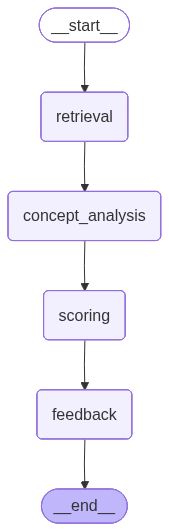

In [15]:
# Cell 12 — Visualize Pipeline Graph
from IPython.display import Image, display

try:
    display(Image(pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error: {e}")
    print("\nText representation:")
    pipeline.get_graph().print_ascii()

In [16]:
# Cell 12 — Baseline (Simple LLM Grader)

def baseline_grader(question, student_answer):
    print("\n⚡ Running BASELINE (No RAG, Direct LLM)...")

    prompt = ChatPromptTemplate.from_template("""
You are an HCI examiner.

QUESTION:
{question}

STUDENT ANSWER:
{student_answer}

Score the answer out of 40 based on:
- Concept Accuracy
- Completeness
- Clarity
- Terminology

Return ONLY JSON:
{{
  "total": int
}}
""")

    chain = prompt | llm
    result = chain.invoke({
        "question": question,
        "student_answer": student_answer
    })

    import json, re

    try:
        match = re.search(r"\{.*\}", result.content, re.DOTALL)
        baseline_score = json.loads(match.group())
    except:
        baseline_score = {"total": 0}

    print("📊 Baseline Score:", baseline_score)
    return baseline_score

In [17]:
# Cell 13 — Compare Baseline vs Your System

def compare_models(question, student_answer, question_marks=3):
    print("\n" + "="*60)
    print("⚔️ MODEL COMPARISON")
    print("="*60)

    # 🔹 Baseline
    baseline = baseline_grader(question, student_answer)

    # 🔹 Your system
    result = evaluate_answer(question, student_answer, question_marks)

    final_scores = parse_scores(result["scores"])
    final_scores = apply_strict_rules(final_scores)

    print("\n" + "="*60)
    print("📊 FINAL COMPARISON")
    print("="*60)

    print(f"Baseline Score        : {baseline['total']}/40")
    print(f"Your System Score    : {final_scores['total']}/40")

    diff = final_scores['total'] - baseline['total']

    print(f"Difference           : {diff}")

    if diff < 0:
        print("📉 Your system is stricter (GOOD)")
    elif diff > 0:
        print("📈 Your system is more lenient")
    else:
        print("⚖️ Similar scoring")

    return {
        "baseline": baseline,
        "your_system": final_scores
    }

In [18]:
compare_models(
    question="What is HCI and why is it important?",
    student_answer="""HCI stands for Human Computer Interaction. It is the study
of interaction between humans and computers. It helps in making systems easy to use
and improves user satisfaction and efficiency."""
)


⚔️ MODEL COMPARISON

⚡ Running BASELINE (No RAG, Direct LLM)...
📊 Baseline Score: {'total': 38}
🚀 ASSESSMENT PIPELINE STARTING
📝 Question: What is HCI and why is it important?
👤 Answer: HCI stands for Human Computer Interaction. It is the study
of interaction betwee...

🔍 Retrieving relevant content from HCI textbook...
✅ 4 relevant chunks retrieved!
🧠 Analyzing concepts...
✅ Concept analysis done!
🎯 Scoring student answer...
✅ Scoring done!
💬 Generating grounded feedback...
✅ Feedback generated!

📊 SCORES (After Strict Evaluation):
{'concept_accuracy': 10, 'completeness': 3, 'logical_coherence': 8, 'terminology': 8, 'total': 20}

💬 FEEDBACK:
1. ✅ The student correctly defined HCI as the study of interaction between humans and computers. They also mentioned that HCI helps in making systems easy to use, improves user satisfaction, and efficiency.

2. ❌ Important concepts missing include the broader impact of HCI on society, such as promoting political participation, citizen science, sp

{'baseline': {'total': 38},
 'your_system': {'concept_accuracy': 10,
  'completeness': 3,
  'logical_coherence': 8,
  'terminology': 8,
  'total': 20}}

In [19]:
good = compare_models(
    question="What is HCI and why is it important?",
    student_answer="""HCI (Human Computer Interaction) is the study of interaction between humans and computers.
It includes designing systems that are easy to use and understand. It involves fields like computer science,
psychology and design.

HCI is important because it helps in making user-friendly systems, reduces errors, improves efficiency and
user satisfaction. It also ensures accessibility for different types of users. Overall it improves user experience."""
)


⚔️ MODEL COMPARISON

⚡ Running BASELINE (No RAG, Direct LLM)...
📊 Baseline Score: {'total': 38}
🚀 ASSESSMENT PIPELINE STARTING
📝 Question: What is HCI and why is it important?
👤 Answer: HCI (Human Computer Interaction) is the study of interaction between humans and ...

🔍 Retrieving relevant content from HCI textbook...
✅ 4 relevant chunks retrieved!
🧠 Analyzing concepts...
✅ Concept analysis done!
🎯 Scoring student answer...
✅ Scoring done!
💬 Generating grounded feedback...
✅ Feedback generated!

📊 SCORES (After Strict Evaluation):
{'concept_accuracy': 10, 'completeness': 6, 'logical_coherence': 8, 'terminology': 8, 'total': 28}

💬 FEEDBACK:
1. ✅ What the student did RIGHT:
The student correctly defined HCI as the study of interaction between humans and computers. They also mentioned the importance of designing user-friendly systems, reducing errors, improving efficiency, user satisfaction, and ensuring accessibility for different types of users.

2. ❌ What is MISSING:
The student mi

In [20]:
avg = compare_models(
    question="What is HCI and why is it important?",
    student_answer="""HCI stands for Human Computer Interaction. It is the study of interaction between humans and computers.

It is important because it makes systems easy to use. It also improves user satisfaction and efficiency.
Good design reduces errors and makes work faster."""
)


⚔️ MODEL COMPARISON

⚡ Running BASELINE (No RAG, Direct LLM)...
📊 Baseline Score: {'total': 35}
🚀 ASSESSMENT PIPELINE STARTING
📝 Question: What is HCI and why is it important?
👤 Answer: HCI stands for Human Computer Interaction. It is the study of interaction betwee...

🔍 Retrieving relevant content from HCI textbook...
✅ 4 relevant chunks retrieved!
🧠 Analyzing concepts...
✅ Concept analysis done!
🎯 Scoring student answer...
✅ Scoring done!
💬 Generating grounded feedback...
✅ Feedback generated!

📊 SCORES (After Strict Evaluation):
{'concept_accuracy': 10, 'completeness': 3, 'logical_coherence': 2, 'terminology': 6, 'total': 20}

💬 FEEDBACK:
1. ✅ The student correctly defined HCI as the study of interaction between humans and computers. They also mentioned the importance of HCI in making systems easy to use, improving user satisfaction, efficiency, and reducing errors.

2. ❌ Important concepts missing include the broader impact of HCI on society, such as promoting political participa

In [21]:
poor = compare_models(
    question="What is HCI and why is it important?",
    student_answer="""HCI is about computers and humans. It is important because computers are used everywhere.
So HCI is useful."""
)


⚔️ MODEL COMPARISON

⚡ Running BASELINE (No RAG, Direct LLM)...
📊 Baseline Score: {'total': 20}
🚀 ASSESSMENT PIPELINE STARTING
📝 Question: What is HCI and why is it important?
👤 Answer: HCI is about computers and humans. It is important because computers are used ev...

🔍 Retrieving relevant content from HCI textbook...
✅ 4 relevant chunks retrieved!
🧠 Analyzing concepts...
✅ Concept analysis done!
🎯 Scoring student answer...
✅ Scoring done!
💬 Generating grounded feedback...
✅ Feedback generated!

📊 SCORES (After Strict Evaluation):
{'concept_accuracy': 6, 'completeness': 3, 'logical_coherence': 2, 'terminology': 5, 'total': 14}

💬 FEEDBACK:
1. ✅ The student correctly mentioned that HCI is about computers and humans, which is a key concept in the field.

2. ❌ What is MISSING: The student did not elaborate on the broader importance of HCI beyond just being used everywhere. HCI plays a crucial role in empowering billions of people with life-changing technologies, promoting societal bene

In [22]:
import pandas as pd

data = [
    {
        "Answer Type": "Good Answer",
        "Baseline": good["baseline"]["total"],
        "Your System": good["your_system"]["total"]
    },
    {
        "Answer Type": "Average Answer",
        "Baseline": avg["baseline"]["total"],
        "Your System": avg["your_system"]["total"]
    },
    {
        "Answer Type": "Poor Answer",
        "Baseline": poor["baseline"]["total"],
        "Your System": poor["your_system"]["total"]
    }
]

df = pd.DataFrame(data)
df

,Answer Type,Baseline,Your System
0,Good Answer,38,28
1,Average Answer,35,20
2,Poor Answer,20,14


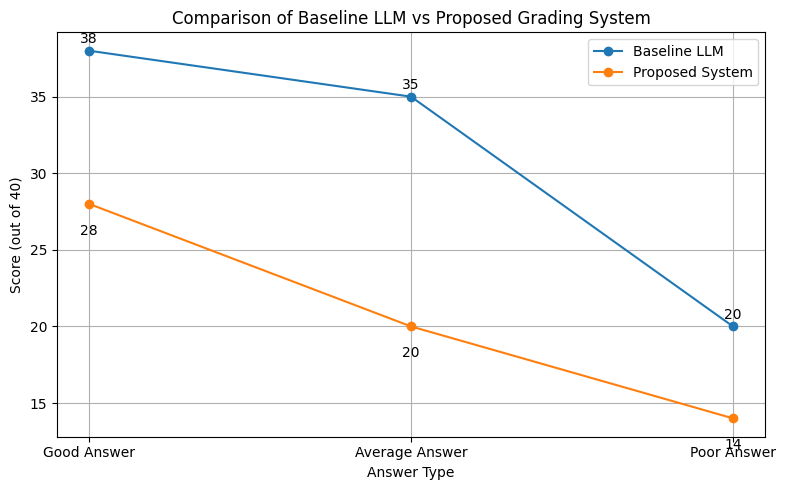

In [25]:
import matplotlib.pyplot as plt

x = df["Answer Type"]
baseline = df["Baseline"]
system = df["Your System"]

plt.figure(figsize=(8,5))

# Lines
plt.plot(x, baseline, marker='o', label="Baseline LLM")
plt.plot(x, system, marker='o', label="Proposed System")

# Labels
plt.xlabel("Answer Type")
plt.ylabel("Score (out of 40)")
plt.title("Comparison of Baseline LLM vs Proposed Grading System")

# Grid (clean look)
plt.grid(True)

# Value labels on points
for i, val in enumerate(baseline):
    plt.text(i, val + 0.5, str(val), ha='center')

for i, val in enumerate(system):
    plt.text(i, val - 2, str(val), ha='center')

# Legend
plt.legend()

plt.tight_layout()
plt.show()